# Control Structures

In [1]:
import sys
from pathlib import Path

current = Path.cwd()
for parent in [current, *current.parents]:
    if (parent / '_config.yml').exists():
        project_root = parent  # ← Add project root, not chapters
        break
else:
    project_root = Path.cwd().parent.parent

sys.path.insert(0, str(project_root))

import thinkpython, diagram, jupyturtle

The three fundamental control structures in computer programming, dictating the order in which instructions are executed within a program, are:

1. Sequence logic (sequential flow)
2. Selection logic (conditional flow)
3. Iteration logic (repetitive flow)

As a fundamental concept, programming languages execute statements sequentially by default. Lines of instructions are executed in a defined `sequential` order unless `selection/conditional` statements (if/elif/else), `iteration` statements (for/while loops). 

In addition to conditional and iteration, there are other flow control tools such as 
- Loop control statements (break, continue) to exit or skip iterations.
- Function control (return) to exit a function early.
- Exceptions (try/except/raise) to handle or redirect error flow. 

## Conditional Statements

Conditional statements allow your Python programs to make decisions and execute different code based on whether certain conditions are true or false. Python uses `if`, `elif`, and `else` statements to evaluate conditions and choose which block of code to run. 

The main topic of conditionals is the `if` statement, which executes different code depending on the program's state. `if` is a Python keyword. `if` statements have the same structure as function definitions: a
**header** followed by an indented statement or sequence of statements called a **block**.

The boolean expression after `if` is called the **condition**.
If it is true, the statements in the indented block run. If not, they don't. 
There is no limit to the number of statements that can appear in the block, but there has to be at least one. Occasionally, it is useful to have a block that does nothing -- usually as a placeholder for code you haven't written yet.
In that case, you can use the `pass` statement, which does nothing.

To write useful programs, we almost always need the ability to check conditions and adjust the program's behavior accordingly, which involves: 
- boolean expressions for `True`/`False` decision, and 
- logical operators for combining Boolean expressions.

Python uses if statements to handle conditional logic, offering several structures to control program flow: 
1. conditional execution (`if`),
2. alternative execution (`if`/`else`),
3. chained execution (`if`/`elif`/`else`),
4. nested conditions, and
5. the `match` Statement*

*not covered presently

### Boolean Expressions

A **boolean expression** is an expression that is either `True` or `False`.
For example, the following expressions use the equals operator, `==`, which compares two values and produces `True` if they are equal and `False` otherwise. Remember that there are six relational/comparison operators: `==` `!=` `>` `<` `>=` `<=`.

In [2]:
t_f_1 = 5 == 5
t_f_2 = 5 == 7
print(t_f_1, t_f_2)

True False


A common error is to use a **single equal sign** (`=`) instead of a **double equal sign** (`==`).
Remember that `=` assigns a value to a variable and `==` compares two values.

In [3]:
x = 5       ### assignment
y = 7       ### assignment

In [4]:
x == y      ### comparison/relational

False

`True` and `False` are special values that belong to the type `bool`;
they are not strings:

In [5]:
print(type(True))
print(type(False))

<class 'bool'>
<class 'bool'>


The `==` operator is one of the **6 relational operators**; the others are:

In [6]:
x != y               # x is not equal to y
x > y                # x is greater than y
x < y                # x is less than y
x >= y               # x is greater than or equal to y
x <= y               # x is less than or equal to y

True

### Logical operators

To **combine** boolean values into expressions, we can use **logical operators**.
The most common are `and`, ` or`, and `not`.
The meaning of these operators is similar to their meaning in English.
For example, the value of the following expression is `True` only if `x` is greater than `0` *and* less than `10`.

In [7]:
x > 0 and x < 10

True

The following expression is `True` if *either or both* of the conditions is true, that is, if the number is divisible by 2 *or* 3:

In [8]:
x % 2 == 0 or x % 3 == 0

False

Finally, the `not` operator negates a boolean expression, so the following expression is `True` if `x > y` is `False`.

In [9]:
not x > y

True

Strictly speaking, the operands of a logical operator should be boolean expressions, but Python is not very strict.
Any nonzero number is interpreted as `True` (**truthy**):

In [10]:
42 and True

True

This flexibility can be useful, but there are some subtleties to it that can be confusing.
You might want to avoid it.

In [11]:
x = 7                       ### sample value to classify

if x > 10:
    print("x is large")     ### runs only when x is greater than 10
elif x > 5:
    print("x is medium")    ### runs when x is 6–10
else:
    print("x is small")     ### runs when x is 5 or less

x is medium


### Conditional execution (`if`)
Conditional gives us the ability to check the conditions and is the simplest form of the `if` statement:

In [12]:
if x > 0:
    print('x is positive')

x is positive


In [13]:
if x < 0:
    pass          # TODO: need to handle negative values!

The word `TODO` in a comment is a conventional reminder that there’s something you need to do later. Modern IDE's would recognize it and act accordingly.

### Alternative Execution (`else`)

An `if` statement can have a second part, called an `else` clause. If the condition is true, the first indented statement runs; otherwise, the second indented statement runs. For example:

```python
num = int(input("Please enter an integer: "))
if num % 2 == 0:                ### % modulus operator
    print("num is even")
else:
    print("num is odd")
```

In this example, if `num` is even, the remainder when `num` is divided by `2` is `0`, so the condition is `True` and the program displays `num is even`. 

If `num` is odd, the remainder is `1`, so the condition is false, and the program displays `num is odd`.

Since the condition must be true or false, exactly one of the alternatives will run. The alternatives are called **branches**.

### Chained Conditional (`elif`)
Sometimes there are more than two possibilities, and we need more than two branches. One way to express a computation like that is a **chained conditional**, which includes an `elif` clause.

`elif` is an abbreviation of "else if" and is used to add multiple conditions inside an `if` block. There is no limit on the number of `elif` clauses. 

If there is an `else` clause, it has to be at the end, but there doesn’t have to be one.

Note that:
- Each condition is checked in order.
- If the first is false, the next is checked, and so on.
- If one of them is true, the corresponding branch runs, and the `if` statement ends.
- Even if more than one condition is true, only the first true branch runs.

In [15]:
num = int(input("Please enter an integer: "))

if num > 0:
    print("positive")
elif num == 0:
    print("neither positive or negative")
elif num < 0:                               
    print("negative")

Please enter an integer:  3


positive


### Nested Conditionals

One conditional can also be nested within another. We could have written a conditional to compare two numbers:

In [16]:
print(f"x: {x}; y: {y}")

if x == y:
    print('x and y are equal')
else:
    if x < y:
        print('x is less than y')
    else:
        print('x is greater than y')

x: 7; y: 7
x and y are equal


In this example, the outer `if` statement contains two branches:
- The first branch contains a simple statement.
- The second branch contains another `if` statement with two branches of its own.

Those two branches are both simple `print` statements, although they could have been conditional statements as well.

Although the indentation of the statements makes the structure apparent, **nested conditionals** can be difficult to read. I suggest you avoid them whenever possible.

**Logical operators** often simplify nested conditional statements.
Here's an example with a nested conditional.

In [17]:
if 0 < x:
    if x < 10:
        print('x is a positive single-digit number.')


x is a positive single-digit number.


The `print` statement runs only if we make it past both conditionals, so we get the same effect with the `and` operator.

In [18]:
if 0 < x and x < 10:
    print('x is a positive single-digit number.')

x is a positive single-digit number.


For this kind of condition, Python provides a more concise option:

In [19]:
if 0 < x < 10:
    print('x is a positive single-digit number.')

x is a positive single-digit number.


## `while` Loops

A Python while loop repeatedly executes a block of code as long as a specified **condition** remains true. Once the condition evaluates to false, the program continues with the statement following the loop.

The syntax of while loop is:
```python
while [condition]:
    [statement(s)]
```

In the following example, the while loop runs as long as the variable count is less than 5. A `while` loop requires a **counter** and to increment/decrement variable to be ready. In this example, we need to define an **indexing variable**, count, and set it to 1.

In [20]:
count = 1                   ### initialize the variable
while count < 5:            ### condition to check
    print(f'count is: {count}') ### format string to print count
    count = count+1             ### increment count to avoid infinite loop

count is: 1
count is: 2
count is: 3
count is: 4


### While Loop Control Statements

You can control the execution of a `while` loop using the following statements:

- **`break`** – Immediately exits the loop, even if the loop condition is still `True`.  
- **`continue`** – Skips the remainder of the current iteration and returns to the top of the loop to recheck the condition.  
- **`pass`** - Used to write empty loops (also used for empty control statements, functions, and classes).
- **`else` clause** – Executes only if the loop finishes normally (when the condition becomes `False`), and does **not** run if the loop is terminated by a `break` statement.


In [21]:
### break statement example

i = 1
while i < 6:
    print(i)
    if i == 3:
        break
    i += 1


1
2
3


In [22]:
### continue statement example

i = 0
while i < 6:
  i += 1
  if i == 3:
    continue
  print(i)

1
2
4
5
6


In [23]:
### pass statement example

a = 'geeksforgeeks'
i = 0
while i < len(a):
    i += 1
    pass
  
print('Value of i :', i)

Value of i : 13


`pass` works similarly as `continue` in `while` loop with distinctions:
| Feature | `pass` | `continue` |
| :--- | :--- | :--- |
| **Definition** | A null operation; it literally does nothing. | Skips the remainder of the current loop iteration. |
| **Context** | Can be used anywhere (loops, functions, classes, `if` statements). | **Only** allowed inside loops (`for` or `while`). |
| **Impact on Flow** | Execution continues to the next statement in the block. | Execution jumps back to the start of the loop for the next cycle. |
| **Primary Use** | Syntactic placeholder (prevents "empty block" errors). | Logic control (skips specific items based on a condition). |
| **Example Scenario** | Creating an empty function for future implementation. | Printing only odd numbers by skipping even ones. |\

## `for` Loops

Iteration is the process of repeating a set of instructions multiple times, allowing you to efficiently perform the same operation on many items or until a specific condition is met. Instead of writing the same code over and over (like printing numbers 1 through 100 by hand), Python provides `for` and `while` loops that automate repetition, whether you're processing each item in a shopping list, reading lines from a file, or waiting for user input to be valid. 

For iteration, you can think of `for` loops as: "I have a thing to iterate through". Usually, you know its size when it's a sequence like a list, which you can **repeat** for a **fixed number** of times. We often use `for` for iterating over `sequences` like `lists`, `tuples`, `strings`, and `ranges`.

### `range()`
We can use a `for` loop that uses the `range` function to display a sequence of numbers.

In [81]:
### loop through a range
for i in range(3):
    print(i, end=' ')

0 1 2 

You can use a `for` statement to loop through the elements of a list.

In [82]:
### loop through a list
fruits = ["apple", "banana", "cherry"]
for fruit in fruits:
    print(fruit, end=" ")                   ### apple banana cherry

apple banana cherry 

In [83]:
seq = [1, 2, 3, 4, 5]

In [84]:
fruits = ["apple", "banana", "cherry"]
for fruit in fruits:
    print(fruit, end=" ")                   ### apple banana cherry

apple banana cherry 

In [85]:
### iterate over each item in the sequence
for item in seq:    ### item is a temporary loop variable        
    print(item)

1
2
3
4
5


In [86]:
for item in seq:
    print('Yep')

Yep
Yep
Yep
Yep
Yep


In [87]:
for jelly in seq:
    print(jelly+jelly)

2
4
6
8
10


<!-- >>> fruits = ["apple", "banana", "cherry"]
>>> for fruit in fruits:
...     print(fruit)
...     
apple
banana
cherry -->

For example, after using `split` to make a list of words, we can use `for` to loop through them.

In [88]:
s = 'pining for the fjords'

for word in s.split():
    print(word)

pining
for
the
fjords


A `for` loop over an empty list never runs the indented statements.

In [33]:
for x in []:
    print('This never happens.')

### Loops and strings

In 1939, Ernest Vincent Wright published a 50,000-word novel called Gadsby that does not contain the letter “e”. Since “e” is the most common letter in English, writing even a few words without using it is difficult. To get a sense of how difficult, we’ll compute the fraction of English words that have at least one “e”.

For that, we'll use `for` statements to loop through the letters in a string and the words in a file, and we'll update variables in a loop to count the number of words that contain an "e". 

We'll use the `in` operator to check whether a letter appears in a word, and you'll learn a programming pattern called a "linear search".

As an exercise, you’ll use these tools to solve a word puzzle called “Spelling Bee”.

We know that a `for` loop using the `range` function can display a sequence of numbers.

In [34]:
for i in range(3):
    print(i, end=' ')

0 1 2 

This version uses the keyword argument `end` so the `print` function puts a space after each number rather than a newline.

We can also use a `for` loop to display the letters in a string.

In [35]:
for letter in 'Gadsby':
    print(letter, end=' ')

G a d s b y 

Notice that I changed the name of the variable from `i` to `letter`, which provides more information about the value it refers to.
The variable defined in a `for` loop is called the **loop variable**.

Now that we can loop through the letters in a word, we can check whether it contains the letter "e".

In [36]:
for letter in "Gadsby":
    if letter == 'E' or letter == 'e':
        print('This word has an "e"')

Before we go on, let's encapsulate that loop in a function.

In [37]:
def has_e():
    for letter in "Gadsby":
        if letter == 'E' or letter == 'e':
            print('This word has an "e"')

And let's make it a pure function that return `True` if the word contains an "e" and `False` otherwise.

In [38]:
def has_e():
    for letter in "Gadsby":
        if letter == 'E' or letter == 'e':
            return True
    return False

We can generalize it to take the word as a parameter.

In [39]:
def has_e(word):
    for letter in word:
        if letter == 'E' or letter == 'e':
            return True
    return False

Now we can test it like this:

In [40]:
has_e('Gadsby')

False

In [41]:
has_e('Emma')

True

### Reading the word list

To see how many words c
ontain an "e", we'll need a word list.
The one we'll use is a list of about 114,000 official crosswords; that is, words that are considered valid in crossword puzzles and other word games.

The following cell downloads the word list, which is a modified version of a list collected and contributed to the public domain by Grady Ward as part of the Moby lexicon project (see <http://wikipedia.org/wiki/Moby_Project>).

In [42]:
from os.path import basename, exists

def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + str(local))
    return filename

download('https://raw.githubusercontent.com/AllenDowney/ThinkPython/v3/words.txt');

The word list is in a file called `words.txt`, which is downloaded in the notebook for this chapter.
To read it, we'll use the built-in function `open`, which takes the name of the file as a parameter and returns a **file object** we can use to read the file.

In [43]:
file_object = open('words.txt')

The file object provides a function called `readline`, which reads characters from the file until it gets to a newline and returns the result as a string:

In [44]:
file_object.readline()

'aa\n'

Notice that the syntax for calling `readline` is different from functions we've seen so far. That's because it is a **method**, which is a function associated with an object.
In this case `readline` is associated with the file object, so we call it using the name of the object, the dot operator, and the name of the method.

The first word in the list is "aa", which is a kind of lava.
The sequence `\n` represents the newline character that separates this word from the next.

The file object keeps track of where it is in the file, so if you call
`readline` again, you get the next word:

In [45]:
line = file_object.readline()
line

'aah\n'

To remove the newline from the end of the word, we can use `strip`, which is a method associated with strings, so we can call it like this.

In [46]:
word = line.strip()
word

'aah'

`strip` removes whitespace characters -- including spaces, tabs, and newlines -- from the beginning and end of the string.

You can also use a file object as part of a `for` loop. 
This program reads `words.txt` and prints each word, one per line:

In [47]:
# for line in open('words.txt'):
#     word = line.strip()
#     print(word)

Now that we can read the word list, the next step is to count them.
For that, we will need the ability to update variables.

### Updating variables

As you may have discovered, it is legal to make more than one assignment
to the same variable.
A new assignment makes an existing variable refer to a new value (and stop referring to the old value).

For example, here is an initial assignment that creates a variable.

In [48]:
x = 5
x

5

And here is an assignment that changes the value of a variable.

In [49]:
x = 7
x

7

The following figure shows what these assignments looks like in a state diagram.

In [50]:
from diagram import make_rebind, draw_bindings

bindings = make_rebind('x', [5, 7])

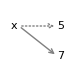

In [51]:
from diagram import diagram, adjust

width, height, x, y = [0.54, 0.61, 0.07, 0.45]
ax = diagram(width, height)
bbox = draw_bindings(bindings, ax, x, y)
# adjust(x, y, bbox)

The dotted arrow indicates that `x` no longer refers to `5`.
The solid arrow indicates that it now refers to `7`.

A common kind of assignment is an **update**, where the new value of
the variable depends on the old.

In [52]:
x = 7

In [53]:
x = x + 1
x

8

This statement means "get the current value of `x`, add one, and assign the result back to `x`."

If you try to update a variable that doesn't exist, you get an error, because Python evaluates the expression on the right before it assigns a value to the variable on the left.

In [54]:
%%expect NameError

z = z + 1

NameError: name 'z' is not defined

Before you can update a variable, you have to **initialize** it, usually
with a simple assignment:

In [55]:
z = 0
z = z + 1
z

1

Increasing the value of a variable is called an **increment**; decreasing the value is called a **decrement**.
Because these operations are so common, Python provides **augmented assignment operators** that update a variable more concisely.
For example, the `+=` operator increments a variable by the given amount.

In [56]:
z += 2
z

3

There are augmented assignment operators for the other arithmetic operators, including `-=` and `*=`.

### Looping and counting

The following program counts the number of words in the word list.

In [57]:
total = 0

for line in open('words.txt'):
    word = line.strip()
    total += 1

It starts by initializing `total` to `0`.
Each time through the loop, it increments `total` by `1`.
So when the loop exits, `total` refers to the total number of words.

In [58]:
total

113783

A variable like this, used to count the number of times something happens, is called a **counter**.

We can add a second counter to the program to keep track of the number of words that contain an "e".

In [59]:
total = 0
count = 0

for line in open('words.txt'):
    word = line.strip()
    total = total + 1
    if has_e(word):
        count += 1

Let's see how many words contain an "e".

In [60]:
count

76162

As a percentage of `total`, about two-thirds of the words use the letter "e".

In [61]:
count / total * 100

66.93618554617122

So you can understand why it's difficult to craft a book without using any such words.

### The in operator

The version of `has_e` we wrote in this chapter is more complicated than it needs to be.
Python provides an operator, `in`,  that checks whether a character appears in a string.

In [62]:
word = 'Gadsby'
'e' in word

False

So we can rewrite `has_e` like this.

In [63]:
def has_e(word):
    if 'E' in word or 'e' in word:
        return True
    else:
        return False

And because the conditional of the `if` statement has a boolean value, we can eliminate the `if` statement and return the boolean directly.

In [64]:
def has_e(word):
    return 'E' in word or 'e' in word

We can simplify this function even more using the method `lower`, which converts the letters in a string to lowercase.
Here's an example.

In [65]:
word.lower()

'gadsby'

`lower` makes a new string -- it does not modify the existing string -- so the value of `word` is unchanged.

In [66]:
word

'Gadsby'

Here's how we can use `lower` in `has_e`.

In [67]:
def has_e(word):
    return 'e' in word.lower()

In [68]:
has_e('Gadsby')

False

In [69]:
has_e('Emma')

True

### Search

Based on this simpler version of `has_e`, let's write a more general function called `uses_any` that takes a second parameter that is a string of letters.
It returns `True` if the word uses any of the letters and `False` otherwise.

In [70]:
def uses_any(word, letters):
    for letter in word.lower():
        if letter in letters.lower():
            return True
    return False

Here's an example where the result is `True`.

In [71]:
uses_any('banana', 'aeiou')

True

And another where it is `False`.

In [72]:
uses_any('apple', 'xyz')

False

`uses_any` converts `word` and `letters` to lowercase, so it works with any combination of cases.

In [73]:
uses_any('Banana', 'AEIOU')

True

The structure of `uses_any` is similar to `has_e`.
It loops through the letters in `word` and checks them one at a time.
If it finds one that appears in `letters`, it returns `True` immediately.
If it gets all the way through the loop without finding any, it returns `False`.

This pattern is called a **linear search**.
In the exercises at the end of this chapter, you'll write more functions that use this pattern.

In [74]:
def uses_any(word, letters):
    """Checks if a word uses any of a list of letters.
    
    >>> uses_any('banana', 'aeiou')
    True
    >>> uses_any('apple', 'xyz')
    False
    """
    for letter in word.lower():
        if letter in letters.lower():
            return True
    return False

Each test begins with `>>>`, which is used as a prompt in some Python environments to indicate where the user can type code.
In a doctest, the prompt is followed by an expression, usually a function call.
The following line indicates the value the expression should have if the function works correctly.

In the first example, `'banana'` uses `'a'`, so the result should be `True`.
In the second example, `'apple'` does not use any of `'xyz'`, so the result should be `False`.

To run these tests, we have to import the `doctest` module and run a function called `run_docstring_examples`.
To make this function easier to use, I wrote the following function, which takes a function object as an argument.

In [75]:
from doctest import run_docstring_examples

def run_doctests(func):
    run_docstring_examples(func, globals(), name=func.__name__)

We haven't learned about `globals` and `__name__` yet -- you can ignore them.
Now we can test `uses_any` like this.

In [76]:
run_doctests(uses_any)

`run_doctests` finds the expressions in the docstring and evaluates them.
If the result is the expected value, the test **passes**.
Otherwise it **fails**.

If all tests pass, `run_doctests` displays no output -- in that case, no news is good news.
To see what happens when a test fails, here's an incorrect version of `uses_any`.

In [77]:
def uses_any_incorrect(word, letters):
    """Checks if a word uses any of a list of letters.
    
    >>> uses_any_incorrect('banana', 'aeiou')
    True
    >>> uses_any_incorrect('apple', 'xyz')
    False
    """
    for letter in word.lower():
        if letter in letters.lower():
            return True
        else:
            return False     # INCORRECT!

And here's what happens when we test it.

In [78]:
run_doctests(uses_any_incorrect)

**********************************************************************
File "__main__", line 4, in uses_any_incorrect
Failed example:
    uses_any_incorrect('banana', 'aeiou')
Expected:
    True
Got:
    False


The output includes the example that failed, the value the function was expected to produce, and the value the function actually produced.

If you are not sure why this test failed, you'll have a chance to debug it as an exercise.